# **Exploratory Data Analysis — Bukit Jaas LULC**

Tujuan: memahami karakteristik data labeled dan raw sebelum modeling.
Mencakup eksplorasi statistik, spasial, dan fitur.

In [19]:
# CONFIG - File Path
labeled_data_path = "../data/labeled/labeled_data_manual_sampling.csv"
raw_data_path     = "../data/raw/raw_bukit_jaas_750_2024.csv"

## **Load Data**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

In [21]:
labeled_dataframe   = pd.read_csv(labeled_data_path)
raw_pixel_dataframe = pd.read_csv(raw_data_path)

print(f"Labeled data : {labeled_dataframe.shape[0]} rows, {labeled_dataframe.shape[1]} columns")
print(f"Raw data     : {raw_pixel_dataframe.shape[0]} rows, {raw_pixel_dataframe.shape[1]} columns")

Labeled data : 207 rows, 17 columns
Raw data     : 11373 rows, 16 columns


In [22]:
labeled_dataframe.head()

,longitude,latitude,B2,B3,B4,B8,B11,B12,NDVI,EVI,SAVI,NBR,ETH_CanopyHeight,Elevation,Slope,Aspect,Class
0,111.696567,-8.047602,1114.0,1284.0,1090.0,4232.0,2937.0,1854.0,0.590380,3.248553,0.885486,0.390733,30,265,35,208,Primary_Forest
1,111.696388,-8.047333,1238.0,1160.0,1082.0,3472.0,2557.0,1523.0,0.524813,8.786765,0.787134,0.390190,33,269,38,231,Primary_Forest
2,111.696747,-8.047243,938.0,940.0,848.0,2879.0,2689.0,1694.0,0.544942,5.442122,0.817304,0.259130,30,298,33,205,Primary_Forest
3,111.696747,-8.047423,906.0,862.0,849.0,2790.0,3030.0,1871.0,0.533388,4.451835,0.799973,0.197168,29,285,36,198,Primary_Forest
4,111.696927,-8.047692,965.0,1056.0,691.0,3696.0,2613.0,1484.0,0.684978,12.407102,1.027350,0.427027,26,264,31,186,Primary_Forest


In [23]:
# CONFIG - EDA Parameters
crs_projection = "EPSG:4326"

feature_columns = [
    "B2", "B3", "B4", "B8", "B11", "B12",
    "NDVI", "EVI", "SAVI", "NBR",
    "ETH_CanopyHeight",
    "Elevation", "Slope", "Aspect"
]
target_column = "Class"
id_columns    = ["longitude", "latitude"]

lulc_class_colors = {
    "Primary_Forest"   : "#1a6e1a",
    "Secondary_Forest" : "#5cb85c",
    "Estate_Crop"      : "#f0ad4e",
    "Paddy_Field"      : "#aed6f1",
    "Settlement"       : "#e74c3c",
    "Bare_Ground"      : "#c8a97e",
}

---
# **Eksplorasi Statistik**

#### **Distribusi Kelas**

Cek jumlah sampel per kelas untuk mendeteksi class imbalance.

In [24]:
class_counts      = labeled_dataframe[target_column].value_counts()
class_proportions = labeled_dataframe[target_column].value_counts(normalize=True).mul(100).round(2)

class_summary = pd.DataFrame({
    "count"      : class_counts,
    "percentage" : class_proportions
})
print(class_summary)

                  count  percentage
Class                              
Secondary_Forest     70       33.82
Primary_Forest       50       24.15
Estate_Crop          40       19.32
Bare_Ground          23       11.11
Paddy_Field          15        7.25
Settlement            9        4.35


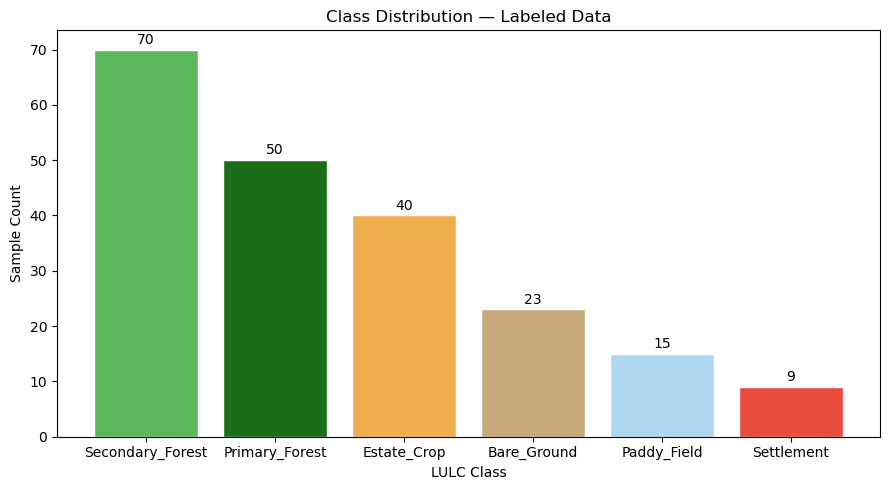

In [25]:
ordered_classes = class_counts.index.tolist()
bar_colors      = [lulc_class_colors.get(cls, "#999999") for cls in ordered_classes]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ordered_classes, class_counts.values, color=bar_colors, edgecolor="white")
ax.set_xlabel("LULC Class")
ax.set_ylabel("Sample Count")
ax.set_title("Class Distribution — Labeled Data")
for index, value in enumerate(class_counts.values):
    ax.text(index, value + 0.5, str(value), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

#### **Statistik Deskriptif per Fitur per Kelas**

In [26]:
descriptive_stats = labeled_dataframe.groupby(target_column)[feature_columns].describe().T
descriptive_stats

Class         Bare_Ground  Estate_Crop  Paddy_Field  Primary_Forest  \
B2     count    23.000000    40.000000    15.000000       50.000000   
       mean   1490.130435  1295.175000   988.600000     1145.900000   
       std    1178.497129   581.044722    79.893501      274.459264   
       min     723.000000   600.000000   820.000000      711.000000   
       25%     989.000000   926.500000   950.500000      920.000000   
...                   ...          ...          ...             ...   
Aspect min      60.000000    63.000000    85.000000       92.000000   
       25%     113.000000   169.000000   122.500000      194.500000   
       50%     245.000000   214.500000   219.000000      207.500000   
       75%     269.500000   249.250000   301.500000      227.750000   
       max     302.000000   326.000000   333.000000      249.000000   

Class         Secondary_Forest   Settlement  
B2     count         70.000000     9.000000  
       mean         948.800000  1470.000000  
       std          246.070074   657.061641  
       min          530.000000   816.000000  
       25%          784.500000  1050.000000  
...                        ...          ...  
Aspect min           23.000000    88.000000  
       25%           80.750000   119.000000  
       50%          109.000000   145.000000  
       75%          195.000000   252.000000  
       max          304.000000   279.000000  

[112 rows x 6 columns]

#### **Missing Values & Outlier Check**

In [27]:
missing_labeled = labeled_dataframe.isnull().sum()
missing_raw     = raw_pixel_dataframe.isnull().sum()

print("Missing values — Labeled data:")
print(missing_labeled[missing_labeled > 0] if missing_labeled.any() else "None")

print("\nMissing values — Raw data:")
print(missing_raw[missing_raw > 0] if missing_raw.any() else "None")

Missing values — Labeled data:
None

Missing values — Raw data:
ETH_CanopyHeight      1
Slope               165
Aspect              165
dtype: int64


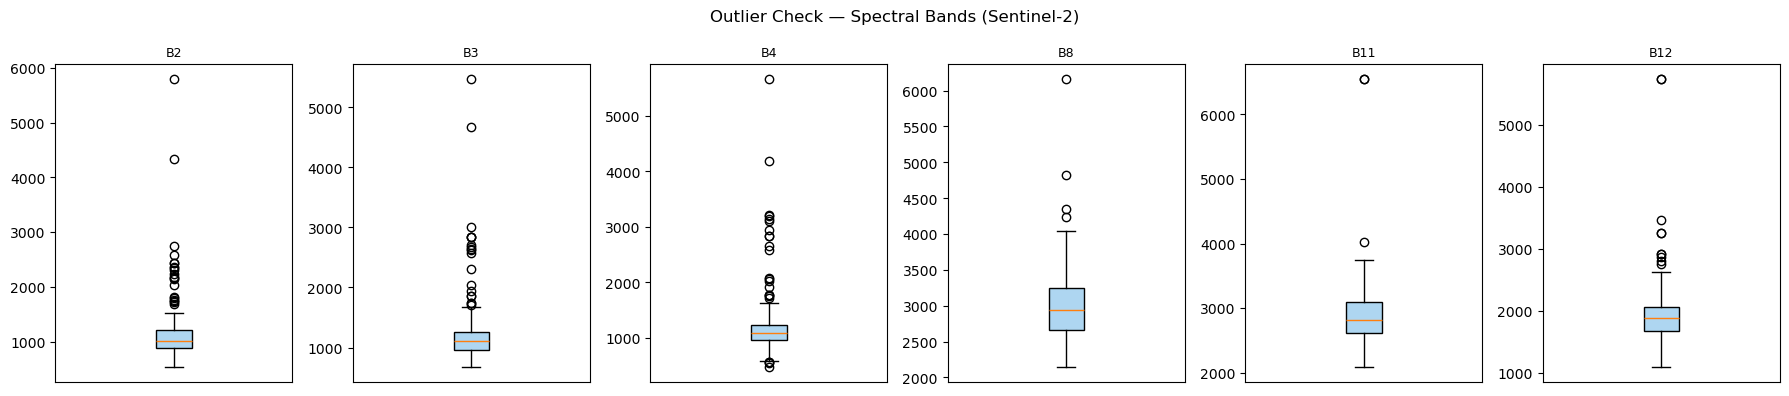

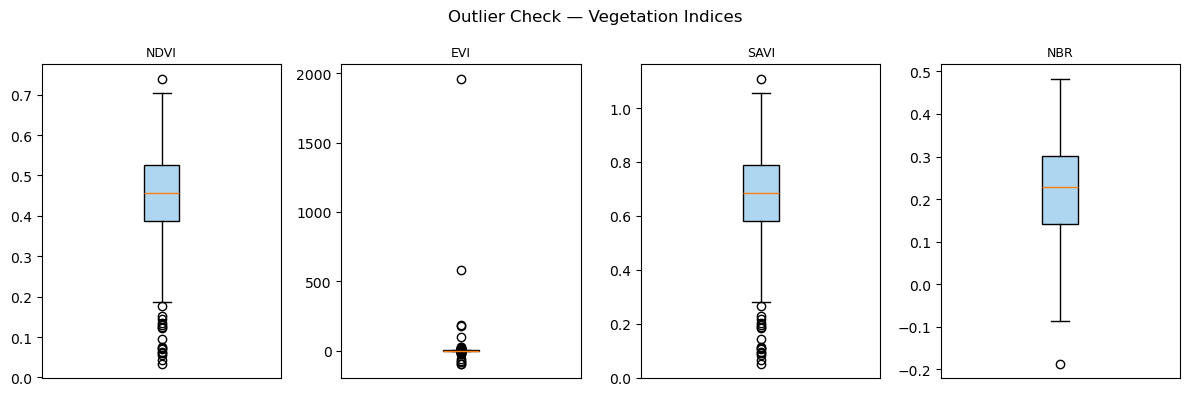

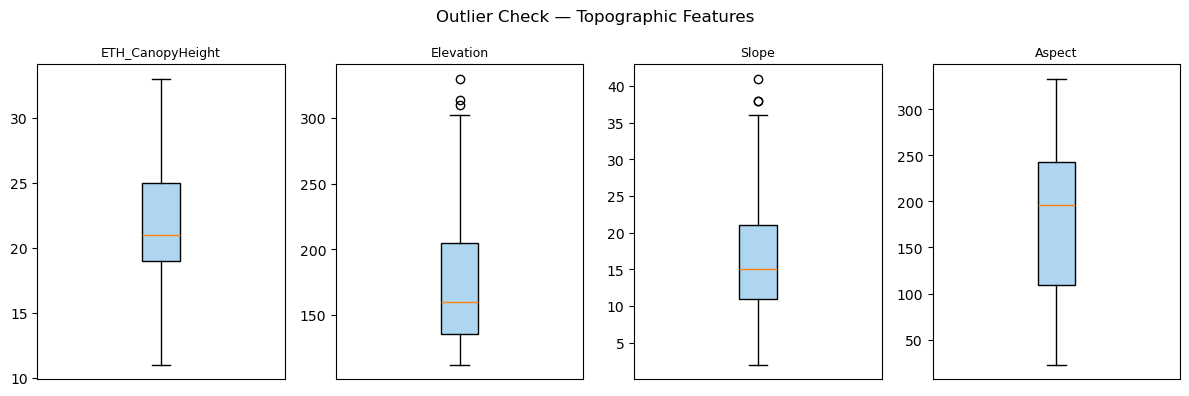

In [28]:
spectral_features    = ["B2", "B3", "B4", "B8", "B11", "B12"]
index_features       = ["NDVI", "EVI", "SAVI", "NBR"]
topographic_features = ["ETH_CanopyHeight", "Elevation", "Slope", "Aspect"]

feature_groups = [
    (spectral_features,    "Spectral Bands (Sentinel-2)"),
    (index_features,       "Vegetation Indices"),
    (topographic_features, "Topographic Features"),
]

for group_features, group_title in feature_groups:
    fig, axes = plt.subplots(1, len(group_features), figsize=(3 * len(group_features), 4))
    fig.suptitle(f"Outlier Check — {group_title}", fontsize=12)
    for ax, feature in zip(axes, group_features):
        ax.boxplot(labeled_dataframe[feature].dropna(), patch_artist=True,
                   boxprops=dict(facecolor="#aed6f1"))
        ax.set_title(feature, fontsize=9)
        ax.set_xticks([])
    plt.tight_layout()
    plt.show()

---
# **Eksplorasi Spasial — GeoPandas**

#### **Konversi ke GeoDataFrame**

In [29]:
labeled_geometry = gpd.GeoDataFrame(
    labeled_dataframe,
    geometry=gpd.points_from_xy(labeled_dataframe["longitude"], labeled_dataframe["latitude"]),
    crs=crs_projection
)

raw_geometry = gpd.GeoDataFrame(
    raw_pixel_dataframe,
    geometry=gpd.points_from_xy(raw_pixel_dataframe["longitude"], raw_pixel_dataframe["latitude"]),
    crs=crs_projection
)

print("Labeled GeoDataFrame CRS :", labeled_geometry.crs)
print("Raw GeoDataFrame CRS     :", raw_geometry.crs)

Labeled GeoDataFrame CRS : EPSG:4326
Raw GeoDataFrame CRS     : EPSG:4326


#### **Plot Titik Sampling per Kelas**

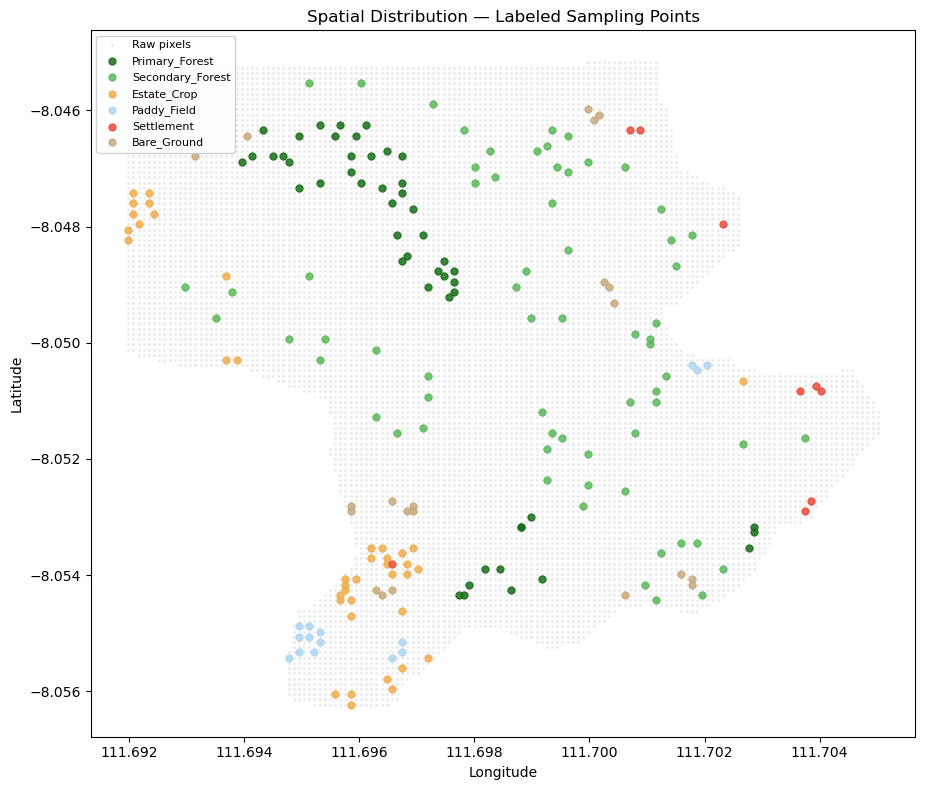

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

raw_geometry.plot(ax=ax, color="#dddddd", markersize=2, alpha=0.4, label="Raw pixels")

for lulc_class, color in lulc_class_colors.items():
    subset = labeled_geometry[labeled_geometry[target_column] == lulc_class]
    subset.plot(ax=ax, color=color, markersize=25, label=lulc_class, alpha=0.85)

ax.set_title("Spatial Distribution — Labeled Sampling Points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

#### **Cek Overlap Koordinat Labeled vs Raw**

Verifikasi bahwa pixel labeled ada di dalam raw dataset (match by koordinat).

In [31]:
labeled_coord_pairs = set(
    zip(labeled_dataframe["longitude"].round(8), labeled_dataframe["latitude"].round(8))
)
raw_coord_pairs = set(
    zip(raw_pixel_dataframe["longitude"].round(8), raw_pixel_dataframe["latitude"].round(8))
)

overlap_count   = len(labeled_coord_pairs & raw_coord_pairs)
not_found_count = len(labeled_coord_pairs - raw_coord_pairs)

print(f"Labeled pixels found in raw data : {overlap_count} / {len(labeled_coord_pairs)}")
print(f"Labeled pixels NOT in raw data   : {not_found_count}")

Labeled pixels found in raw data : 206 / 206
Labeled pixels NOT in raw data   : 0


---
# **Eksplorasi Fitur**

#### **Correlation Matrix Heatmap**

Identifikasi pasangan fitur dengan |r| >= 0.85 — kandidat drop di preprocessing.

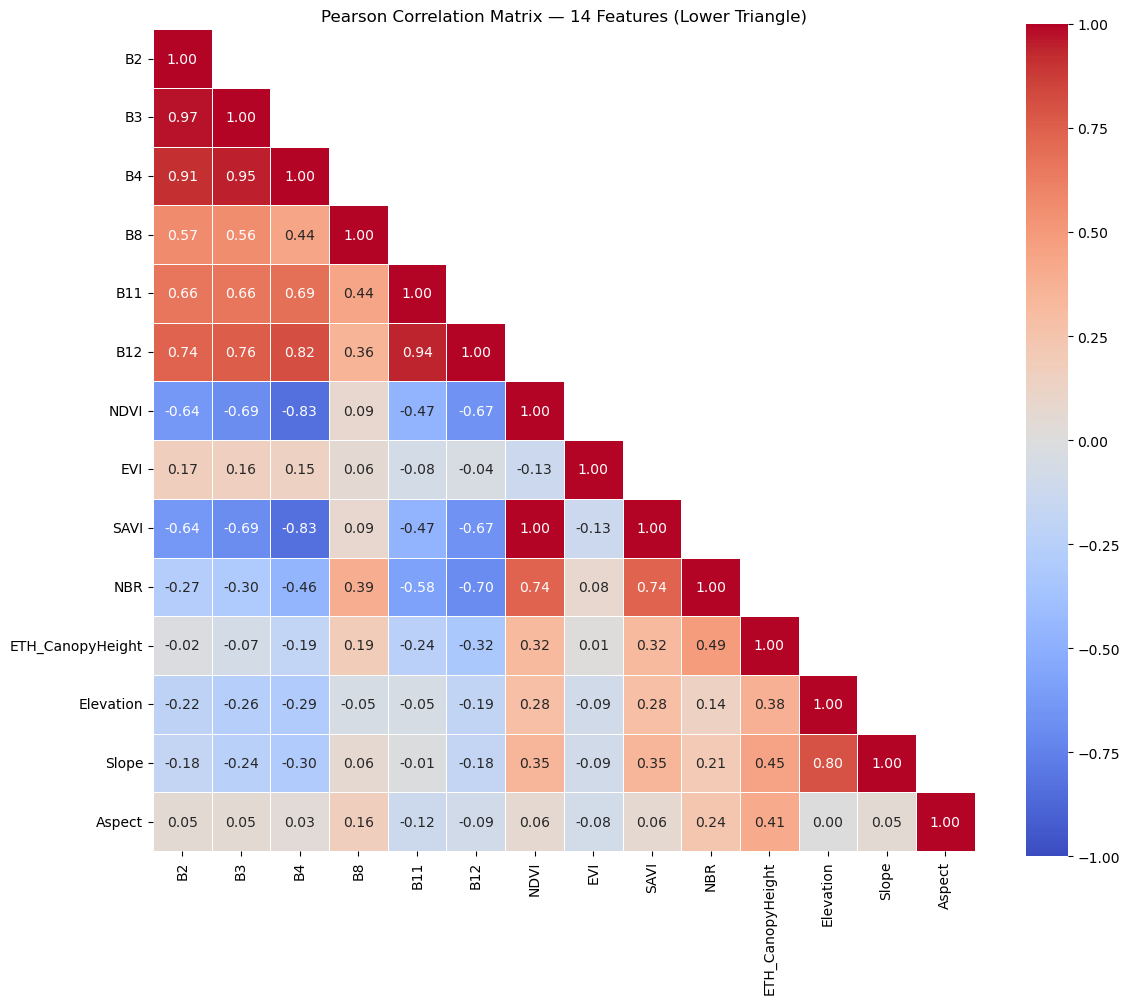

In [32]:
feature_matrix     = labeled_dataframe[feature_columns]
correlation_matrix = feature_matrix.corr()

# Mask upper triangle only (k=1), diagonal tetap tampil
upper_triangle_mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    mask=upper_triangle_mask,
    annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=ax,
    square=True
)
ax.set_title("Pearson Correlation Matrix — 14 Features (Lower Triangle)")
plt.tight_layout()
plt.show()

In [33]:
correlation_threshold = 0.85

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_correlation_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "correlation"})
)
high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs["correlation"].abs() >= correlation_threshold
].sort_values("correlation", ascending=False)

print(f"Feature pairs with |r| >= {correlation_threshold}:")
if high_correlation_pairs.empty:
    print("None found.")
else:
    print(high_correlation_pairs.to_string(index=False))

Feature pairs with |r| >= 0.85:
feature_a feature_b  correlation
     NDVI      SAVI     1.000000
       B2        B3     0.973180
       B3        B4     0.952760
      B11       B12     0.939187
       B2        B4     0.907473


#### **Distribusi Fitur per Kelas (Violin Plot)**

Nilai fitur yang terpisah antar kelas = fitur diskriminatif tinggi.

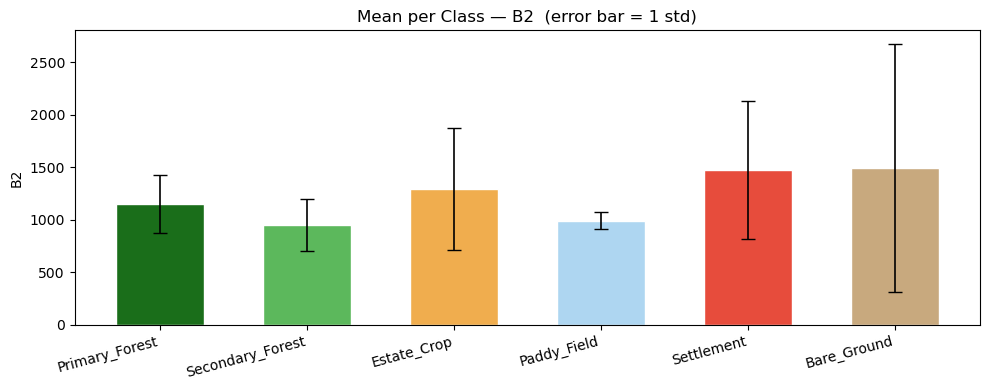

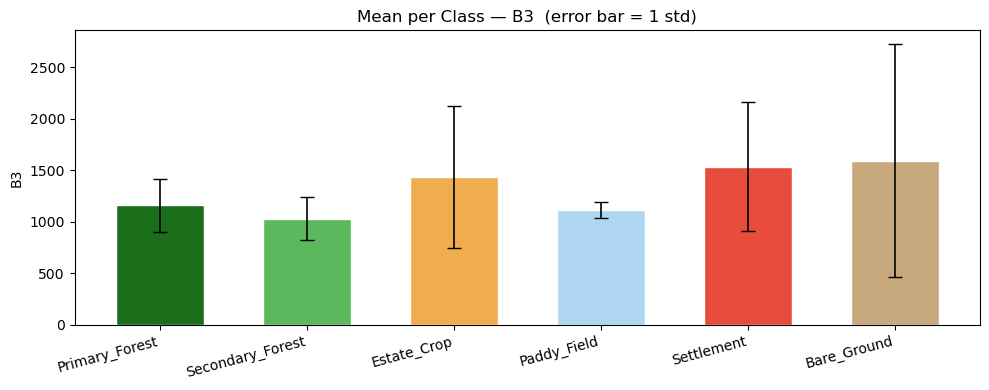

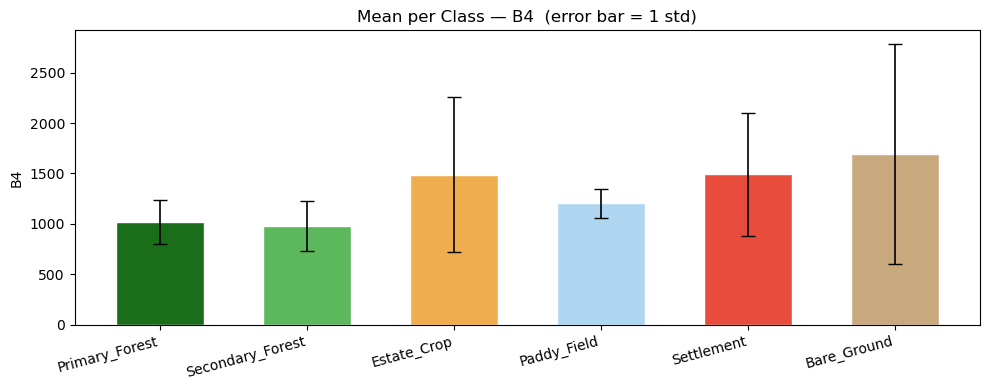

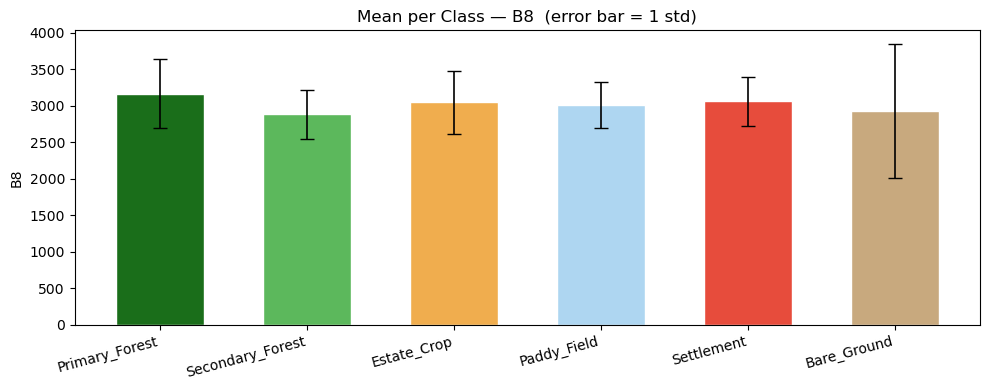

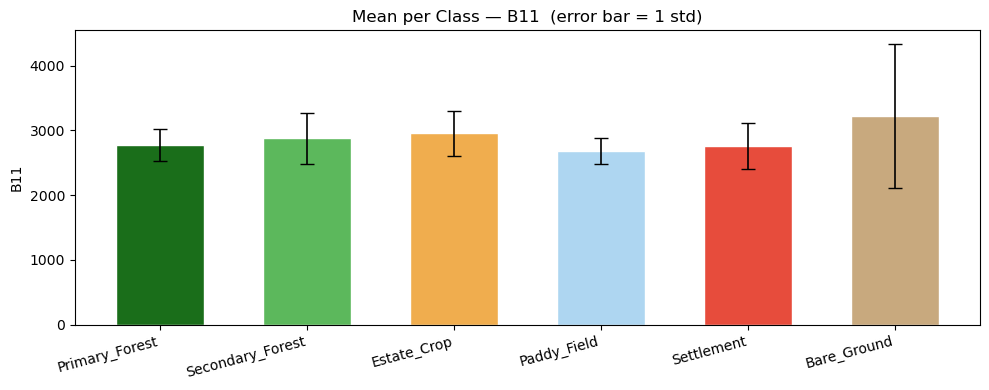

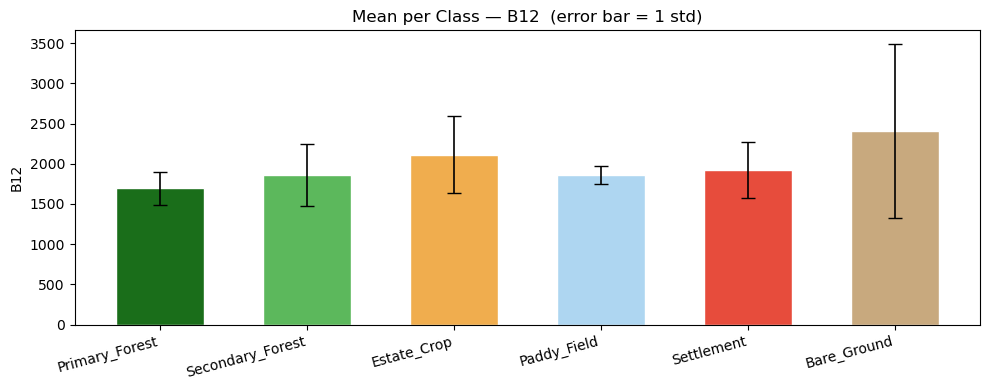

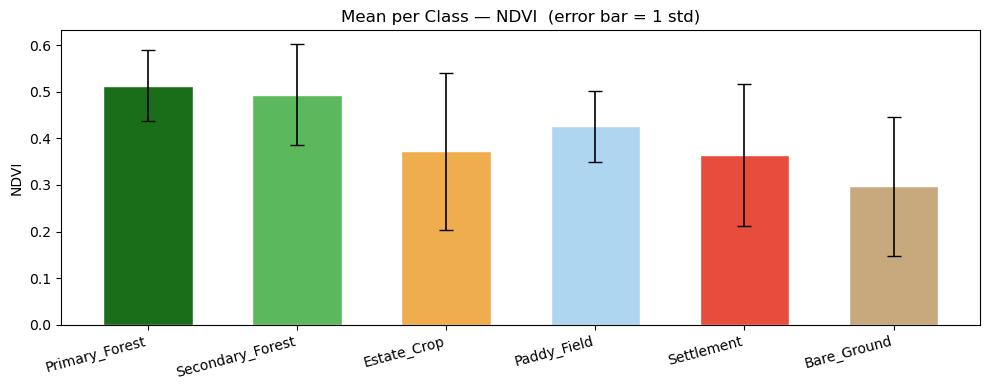

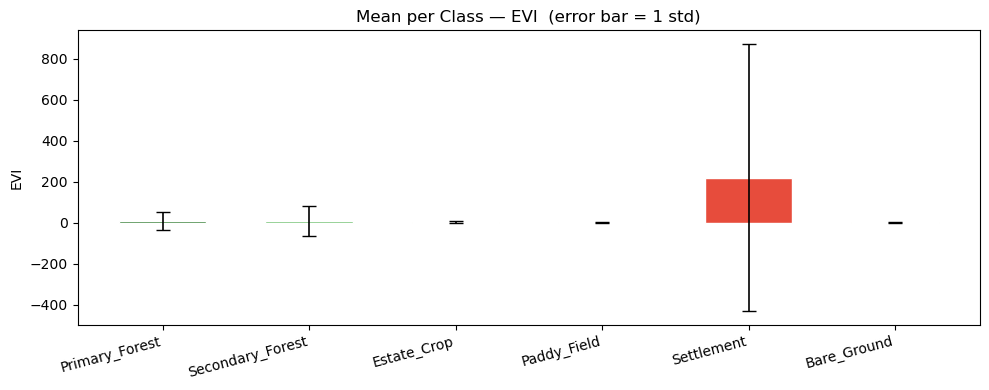

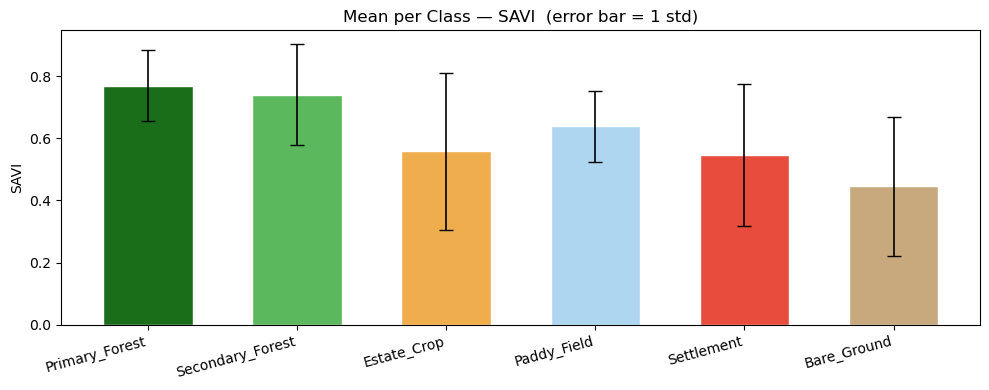

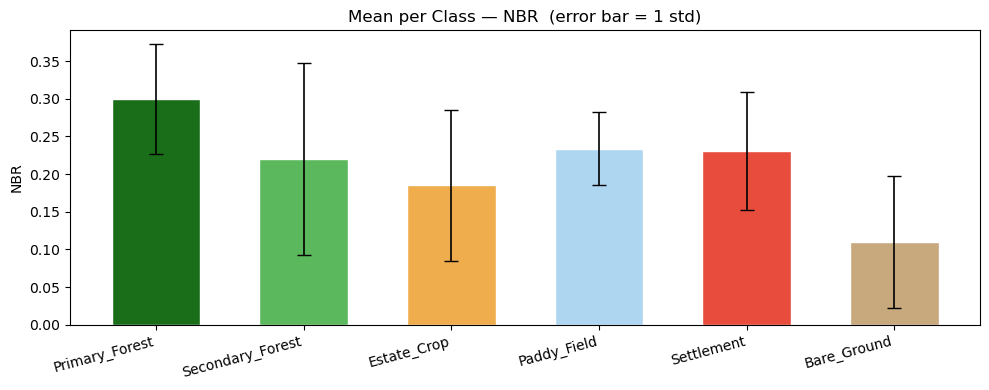

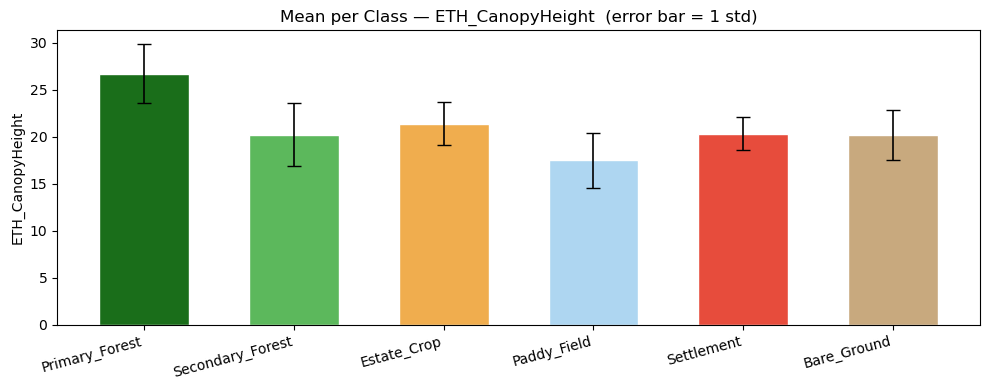

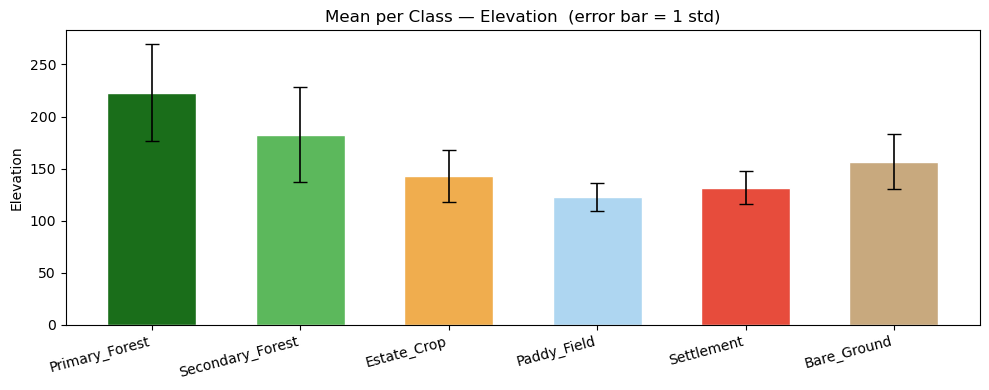

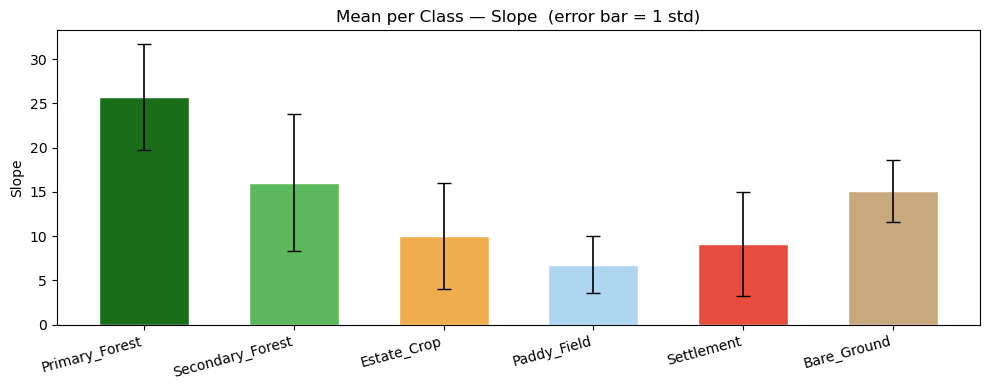

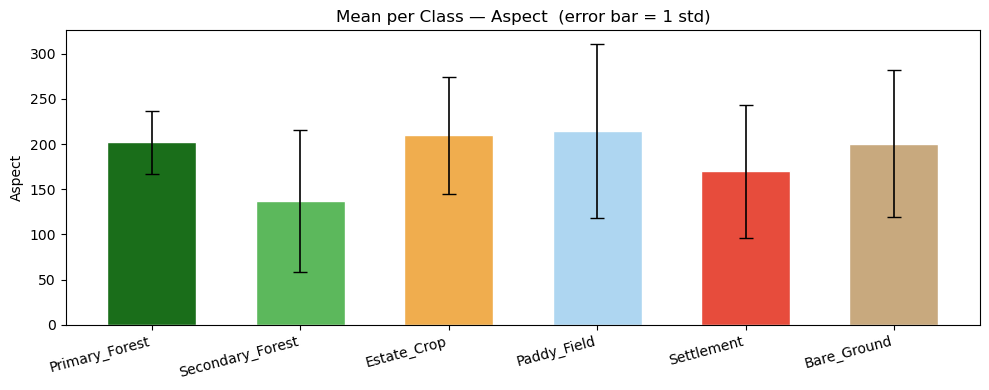

In [34]:
ordered_classes = list(lulc_class_colors.keys())
bar_colors      = list(lulc_class_colors.values())
x_positions     = np.arange(len(ordered_classes))
bar_width       = 0.6

for feature in feature_columns:
    class_means = [
        labeled_dataframe[labeled_dataframe[target_column] == cls][feature].mean()
        for cls in ordered_classes
    ]
    class_stds = [
        labeled_dataframe[labeled_dataframe[target_column] == cls][feature].std()
        for cls in ordered_classes
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(
        x_positions, class_means, width=bar_width,
        color=bar_colors, edgecolor="white",
        yerr=class_stds, capsize=5,
        error_kw={"linewidth": 1.2, "color": "#555"}
    )
    ax.set_xticks(x_positions)
    ax.set_xticklabels(ordered_classes, rotation=15, ha="right")
    ax.set_title(f"Mean per Class — {feature}  (error bar = 1 std)")
    ax.set_ylabel(feature)
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

#### **Sebaran Distribusi Fitur (Histogram per Kelas)**

Histogram tiap fitur di-overlay per kelas. Distribusi yang terpisah antar kelas = fitur diskriminatif tinggi.

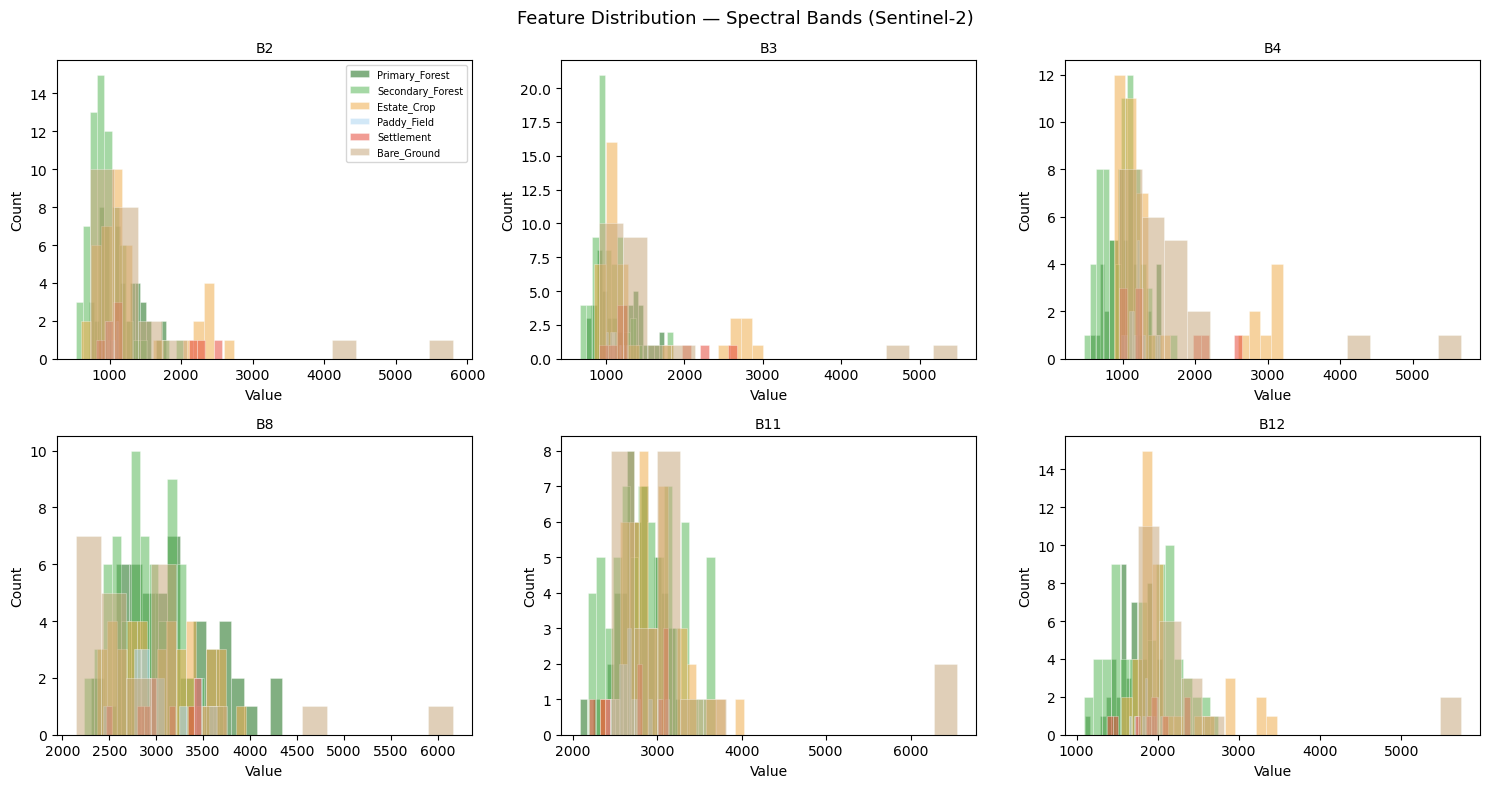

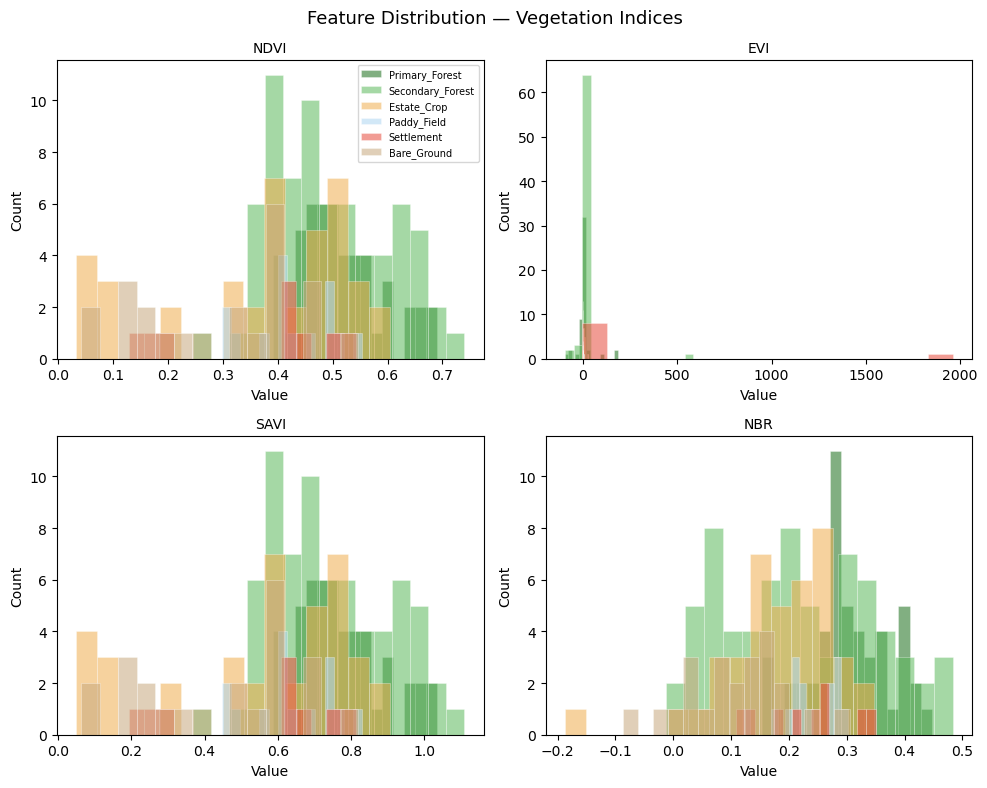

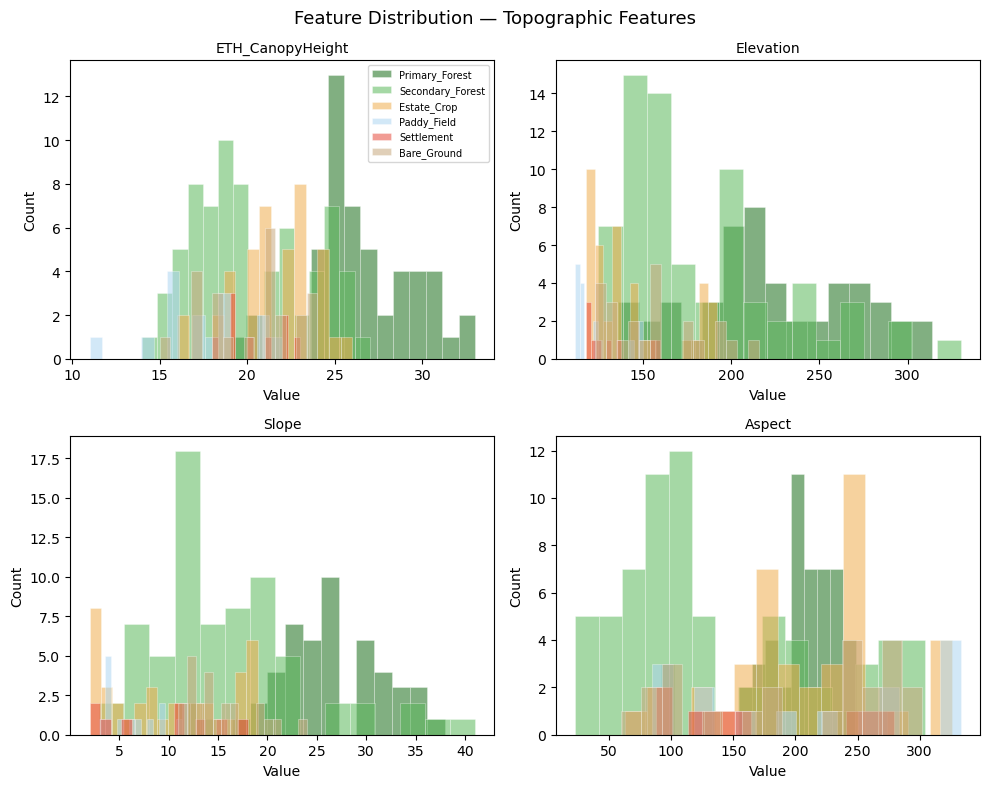

In [36]:
spectral_features    = ["B2", "B3", "B4", "B8", "B11", "B12"]
index_features       = ["NDVI", "EVI", "SAVI", "NBR"]
topographic_features = ["ETH_CanopyHeight", "Elevation", "Slope", "Aspect"]

feature_groups = [
    (spectral_features,    "Spectral Bands (Sentinel-2)",  3, 2),
    (index_features,       "Vegetation Indices",           2, 2),
    (topographic_features, "Topographic Features",         2, 2),
]

for group_features, group_title, n_cols, n_rows in feature_groups:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    fig.suptitle(f"Feature Distribution — {group_title}", fontsize=13)
    axes_flat = axes.flatten()

    for ax, feature in zip(axes_flat, group_features):
        for lulc_class, color in lulc_class_colors.items():
            subset_values = labeled_dataframe[
                labeled_dataframe[target_column] == lulc_class
            ][feature].dropna()
            ax.hist(
                subset_values, bins=15,
                color=color, alpha=0.55, label=lulc_class,
                edgecolor="white", linewidth=0.4
            )
        ax.set_title(feature, fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")

    # Legend di subplot pertama saja
    axes_flat[0].legend(fontsize=7, loc="upper right", framealpha=0.8)

    # Sembunyikan subplot kosong jika ada
    for unused_ax in axes_flat[len(group_features):]:
        unused_ax.set_visible(False)

    plt.tight_layout()
    plt.show()

#### **Identifikasi Fitur Redundan**

Rangkum temuan dari correlation matrix dan violin plot.
Gunakan sebagai dasar keputusan `features_to_drop` di `02_preprocessing.ipynb`.

In [35]:
print("Ringkasan fitur berkorelasi tinggi (kandidat drop):")
if high_correlation_pairs.empty:
    print(f"Tidak ada pasangan fitur dengan |r| >= {correlation_threshold}")
else:
    for _, row in high_correlation_pairs.iterrows():
        print(f"  {row['feature_a']} <-> {row['feature_b']}  r = {row['correlation']:.3f}")

print("\nCatatan: keputusan drop fitur dikonfirmasi di 02_preprocessing.ipynb")

Ringkasan fitur berkorelasi tinggi (kandidat drop):
  NDVI <-> SAVI  r = 1.000
  B2 <-> B3  r = 0.973
  B3 <-> B4  r = 0.953
  B11 <-> B12  r = 0.939
  B2 <-> B4  r = 0.907

Catatan: keputusan drop fitur dikonfirmasi di 02_preprocessing.ipynb
